In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [41]:
df = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_gene_protein.xlsx')
#Eliminamos todas las variables que Norm ya que prefiero hacer nuestra propia normalizacion
df = df.loc[:, ~df.columns.str.contains('Norm')]
#trasponemos para que cada fila sea un paciente y cada columna sea una variable , incluimos el simbolo de hgnc como nombre de columnas  y eliminamos variables que son string
df = df.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T
df1 = df.drop(['ATXN7', 'ATXN7', 'ABCF2', 'ABCF2', 'GGT1', 'GGT1', 'PINX1', 'PINX1',
       'POLR2J3', 'POLR2J3'],axis = 1) #columnas duplicadas
df2 = df[['ATXN7', 'ABCF2', 'GGT1', 'PINX1',  'POLR2J3']]
##Cambiamos los nombres de las columnas duplicadas
cols = ['ATXN7', 'ATXN7', 'ABCF2', 'ABCF2', 'GGT1', 'GGT1', 'PINX1', 'PINX1','POLR2J3', 'POLR2J3']
col_counts = defaultdict(int)
new_cols = []

for col in cols:
    if col_counts[col] == 0:
        new_cols.append(f"{col}_a")
    else:
        new_cols.append(f"{col}_b")
    col_counts[col] += 1
df2.columns = new_cols
df_raw = pd.concat([df1,df2], axis=1)

Text(0.5, 1.0, 'Suma de las lecturas de cada variable ordenadas')

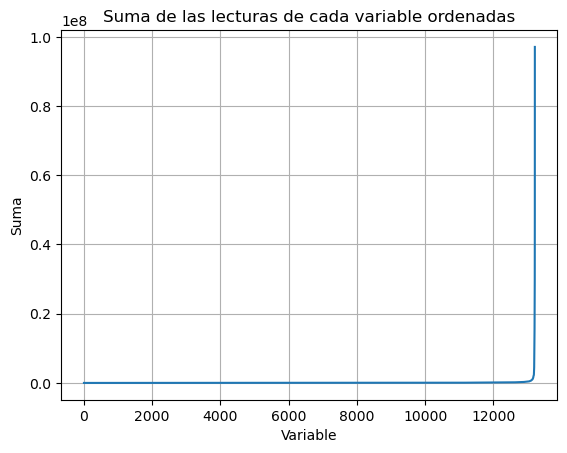

In [42]:

plt.plot(df_raw.sum().sort_values().to_list())
plt.grid(True)
plt.xlabel('Variable')
plt.ylabel('Suma')
plt.title('Suma de las lecturas de cada variable ordenadas')

Text(0.5, 1.0, 'Suma de las lecturas de cada variable ordenadas')

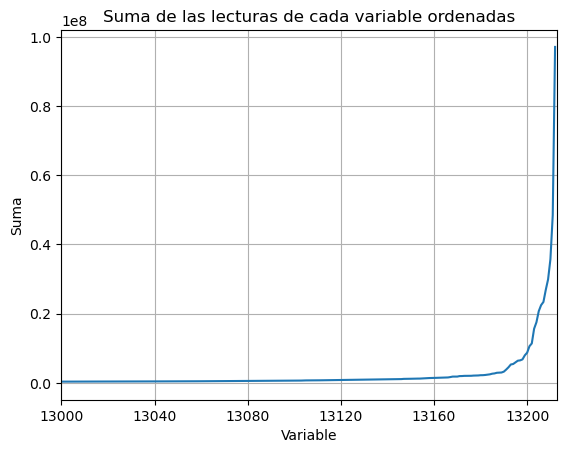

In [43]:
plt.xticks(np.arange(13000, 13213 , 40))
plt.plot(df_raw.sum().sort_values().to_list())
plt.xlim(13000, 13213)
plt.grid(True)
plt.xlabel('Variable')
plt.ylabel('Suma')
plt.title('Suma de las lecturas de cada variable ordenadas')

In [ ]:
x_objetivo = 13000

suma_lecturas = df_raw.sum().sort_values()
suma_lecturas_list = suma_lecturas.to_list()
indice_mas_cercano = np.abs(suma_lecturas.reset_index(drop = True).index - x_objetivo).argmin()
valor_y_MIespondiente = suma_lecturas.iloc[indice_mas_cercano]

print(f"El valor de y correspondiente a x={x_objetivo} es: {valor_y_correspondiente}")

El valor de y correspondiente a x=13000 es: 373526


In [45]:
suma_min = valor_y_correspondiente
filtered = df_raw.sum().sort_values()
cols_interes = filtered[filtered>suma_min].index.to_list()
df_raw_lecAltas1 = df_raw[cols_interes]
len(df_raw_lecAltas1.columns)

212

### MAgnitud mínima

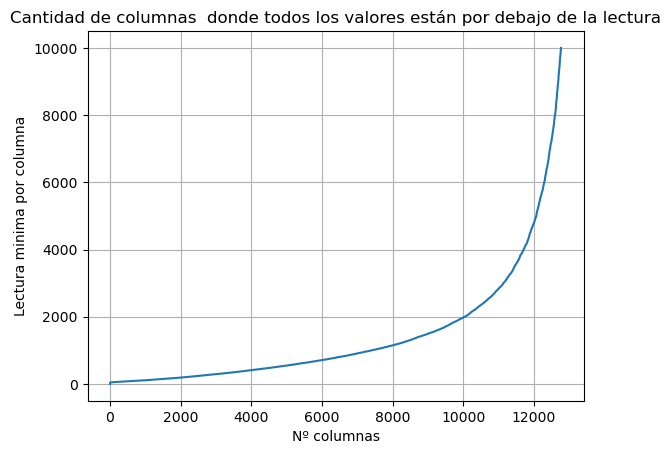

In [52]:
lista_mediaCercACero = []
lecturas_mins = range(0,10000)
for lectMin in lecturas_mins:
    #for frec in np.arange(0,1,0.1):
    mediaCercACero = (df_raw < lectMin).sum() #vemos cuántos valores de cada columna están por debajo de ese umbral
    mediaCercACero = mediaCercACero[mediaCercACero == len(df_raw)] #Filtramos las columnas en donde todos los valores están por debajo de ese umbral
    lista_mediaCercACero.append(len(mediaCercACero))
#plt.xticks(np.arange(0,20,1))
plt.plot(lista_mediaCercACero, lecturas_mins)
plt.xlabel('Nº columnas')
plt.ylabel('Lectura minima por columna')
plt.title('Cantidad de columnas  donde todos los valores están por debajo de la lectura') 
plt.grid(True)
plt.show()

In [62]:
ncol = 12000
indice_mas_cercano = np.abs(np.array(lista_mediaCercACero) - ncol).argmin()
lectura_correspondiente = lecturas_mins[indice_mas_cercano] 
print(f"El valor de lectura correspondiente a x={ncol} es aproximadamente: {lectura_correspondiente}")

El valor de lectura correspondiente a x=12000 es aproximadamente: 4773


In [63]:
lecturaMinElegida = lectura_correspondiente
#Filtrar aquellas celdas que están por debajo de la lectura minima y sumar para cada variable qué registras están por debajo
colAEliminar = (df_raw < lecturaMinElegida).sum() 
#Aquellas columnas en las que todos sus registros están por debajo de la lectura mínima las eliminamos
colAEliminar = colAEliminar[colAEliminar == len(df_raw)].index.to_list() 
df_raw_lecAltas2 = df_raw.drop(colAEliminar,axis = 1)
len(df_raw_lecAltas2.columns)

1213

In [64]:
lecturaMinElegida = lectura_correspondiente
#Filtrar aquellas celdas que están por debajo de la lectura minima y sumar para cada variable qué registras están por debajo
colAEliminar = (df_raw < lecturaMinElegida).sum() 
#Aquellas columnas en las que todos sus registros están por debajo de la lectura mínima las eliminamos
colAEliminar = colAEliminar[colAEliminar == len(df_raw)].index.to_list() 
df_raw_lecAltas2 = df_raw.drop(colAEliminar,axis = 1)
len(df_raw_lecAltas2.columns)

1213

In [65]:
colsLectAlta = list(set(df_raw_lecAltas1.columns.to_list() + df_raw_lecAltas2.columns.to_list()))
len(colsLectAlta)
print(len(df_raw.columns),'->',len(colsLectAlta))

13213 -> 1213


### Varianzas bajas

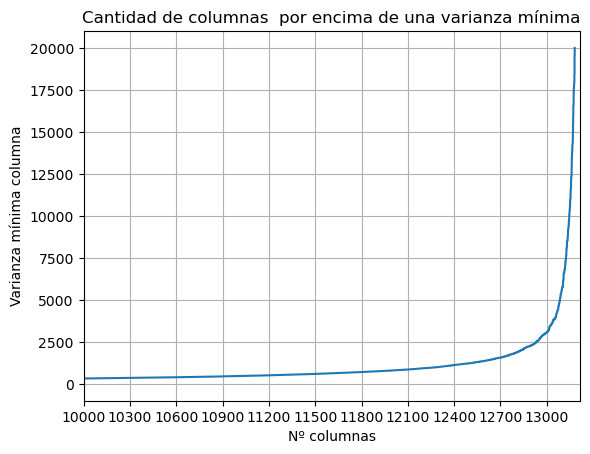

In [75]:
lista_vars = []
vars_mins = range(0,20000)
df_vars = df_raw.std()
for varMin in vars_mins:
    nVarsStd = len(df_vars[df_vars<varMin])
    lista_vars.append(nVarsStd)

plt.xticks(np.arange(10000, 13213,300))
plt.plot(lista_vars, vars_mins)
plt.xlim(10000, 13213)
plt.xlabel('Nº columnas')
plt.ylabel('Varianza mínima columna')
plt.title('Cantidad de columnas  por encima de una varianza mínima') 
plt.grid(True)
plt.show()

In [76]:
lista_vars_array = np.array(lista_vars)
vars_mins_array = np.array(vars_mins)
x_objetivo = 12800
indice_mas_cercano = np.abs(lista_vars_array - x_objetivo).argmin()
varianza_minima_correspondiente = vars_mins_array[indice_mas_cercano]

print(f"La varianza mínima correspondiente a x={x_objetivo} columnas es: {varianza_minima_correspondiente}")

La varianza mínima correspondiente a x=12800 columnas es: 1854


In [77]:
colsVarAlta = df_vars[df_vars>varianza_minima_correspondiente].index.to_list()
print(len(df_raw.columns),'->',len(colsVarAlta))


13213 -> 413


In [78]:
colsSeleccion = list(set(colsLectAlta + colsVarAlta))
df_raw_new = df_raw[colsSeleccion]
len(colsSeleccion)

1213

### Renormalizar

In [79]:
df_raw_new.to_csv('df_raw_Proteines_Normalizar.csv',index = False)

In [125]:
df_norm_TMM = pd.read_csv('cpm_tmmProteines.csv',index_col = 0)

In [126]:
df_norm_TMM.index = df_raw_new.index

### Tests

In [127]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, anderson_ksamp
from statsmodels.stats.multitest import multipletests

In [128]:
df_norm_seleccion = df_norm_TMM
df1_ct = df_norm_seleccion.copy().reset_index()
df1_ct['Grupo'] = np.where(df1_ct['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1_ct['index'].str.contains('C'), 'Control', 'Otro'))
df1_ct = df1_ct.set_index('index')
df1_trnto = df1_ct[df1_ct['Grupo'] == 'Tratamiento'].drop('Grupo', axis = 1)
df1_ctrl = df1_ct[df1_ct['Grupo'] == 'Control'].drop('Grupo', axis = 1)
df1_ct = df1_ct.drop('Grupo', axis = 1)

variables = df1_ct.columns  
variablesIncluir = []
variablesExcluir = []
p_values = []
tests = []  # Para almacenar qué test se usó en cada variable

for var in variables:
    # Prueba de normalidad en ambos grupos
    p_value_trnto = shapiro(df1_trnto[var]).pvalue
    p_value_ctrl = shapiro(df1_ctrl[var]).pvalue
    # Primero comprobamos si los dos grupos siguen una distribución normal o no usando el test Shapiro-Wilk (para muestras pequeñas)
    
    if p_value_trnto > 0.05 and p_value_ctrl > 0.05:   # Si es normal, usamos t-student
        #Los dos p_values son normales → Usamos T_student
        stat, p_value = ttest_ind(df1_trnto[var], df1_ctrl[var], equal_var=False)  # Si el p-valor es menor que 0.05, diferencias significativas, Hay diferencias significativas entre los dos grupos
        test_name = 't-test'
    else:
        # Al menos un grupo no es normal → Usamos Mann-Whitney U
        stat, p_value = mannwhitneyu(df1_trnto[var], df1_ctrl[var], alternative='two-sided')
        test_name = 'Mann-Whitney'

    tests.append(test_name)
    p_values.append(p_value)  # Guardamos el p-valor obtenido

# Como se hacen muchas pruebas de manera reiterada, aplicamos la corrección FDR de Benjamini-Hochberg para evitar una acumulación de falsos positivos
reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

# Clasificar variables según la corrección FDR
variablesIncluir = [var for var, r in zip(variables, reject) if r]
variablesExcluir = [var for var, r in zip(variables, reject) if not r]

# Guardar los resultados en un DataFrame
df_resultados = pd.DataFrame({
    'Variable': variables,
    'Test aplicado': tests,
    'p-valor original': p_values,
    'p-valor ajustado (FDR)': p_adjusted,
    'Rechazar H0 (FDR)': reject #Esto es si rechazamos la hipótesis nula de que no haya diferencias signitficativas, si es true, las hay, si es false, no las hay
})

print(len(variables),'→',len(variablesIncluir))

1213 → 78


### Correlaciones

In [122]:
df1 = df_norm_TMM[variablesIncluir]

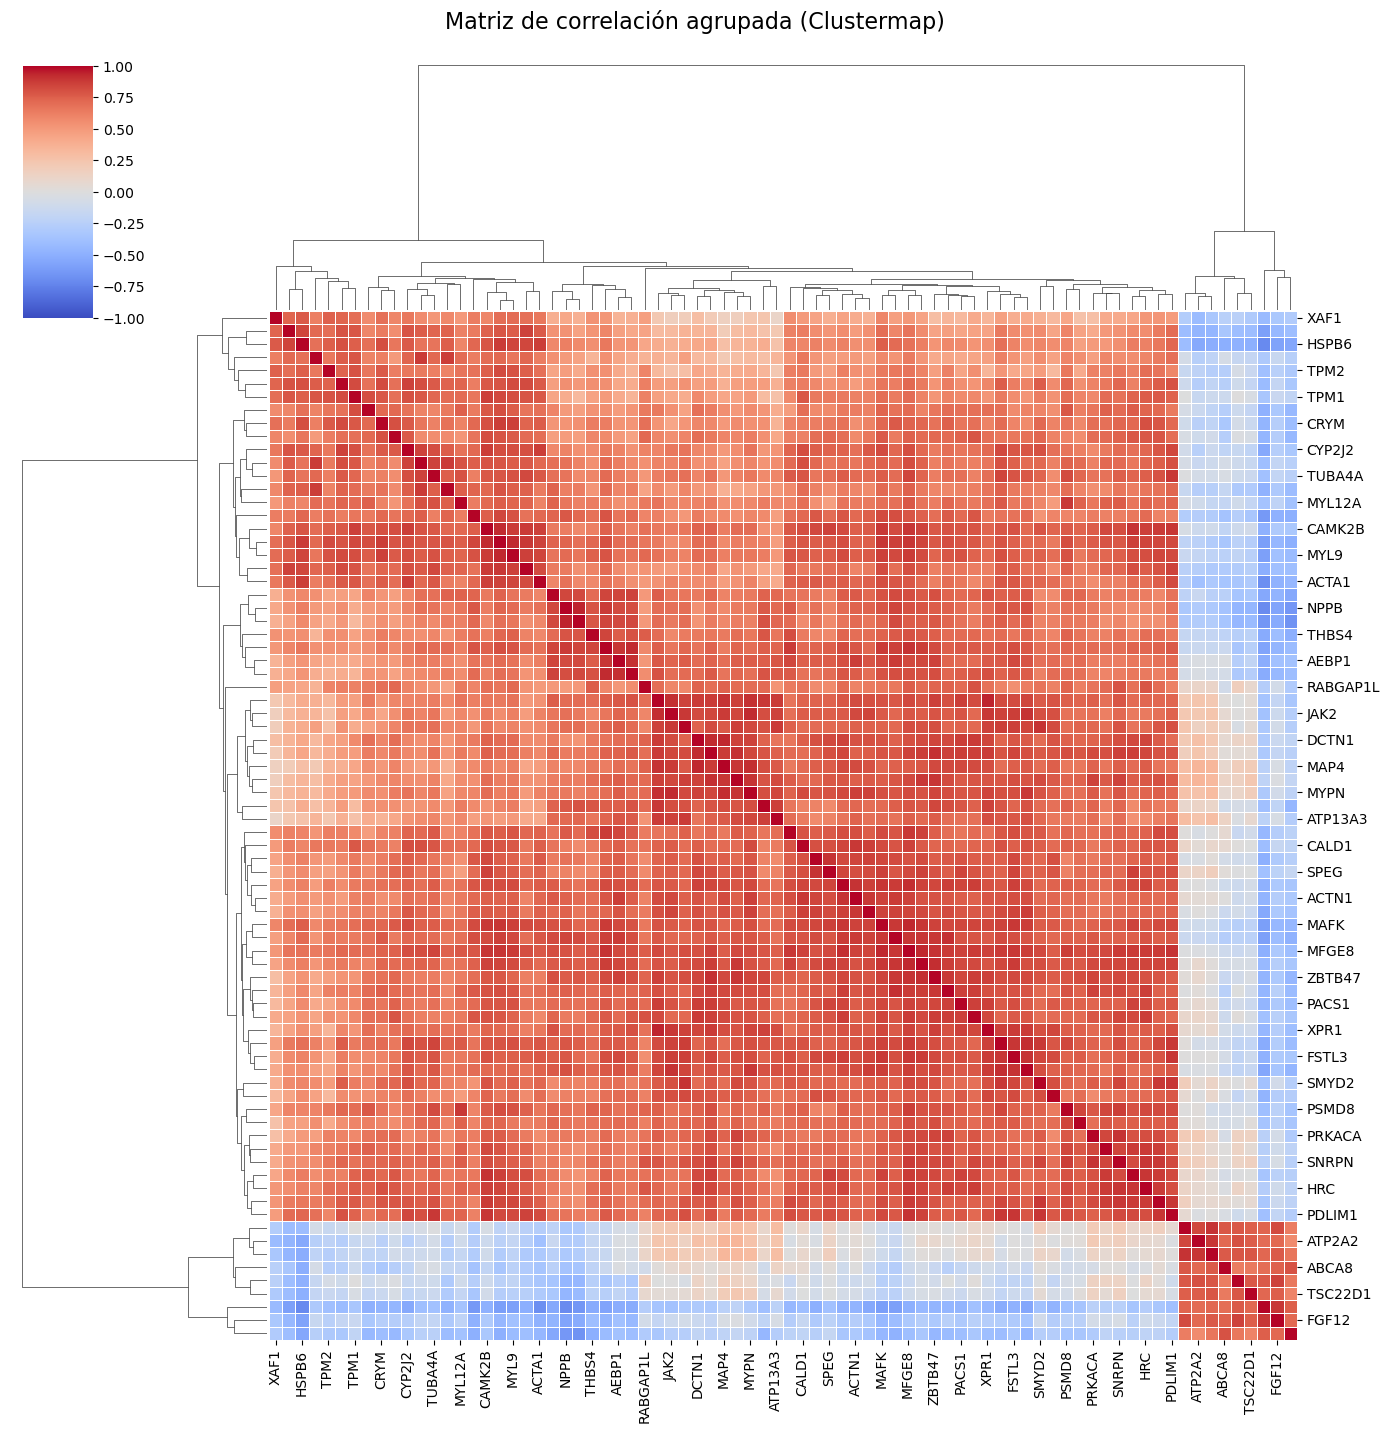

In [124]:
import seaborn as sns

corr = df1.corr(method='spearman')
cluster = sns.clustermap(corr,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7})
cluster.fig.suptitle('Matriz de correlación agrupada (Clustermap)', y=1.02, fontsize=16)
cluster.fig.savefig("graphics/clustermap_correlacionProteinas.png", bbox_inches='tight', dpi=300)
plt.show()

Correlacion + infoMutua

c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was 

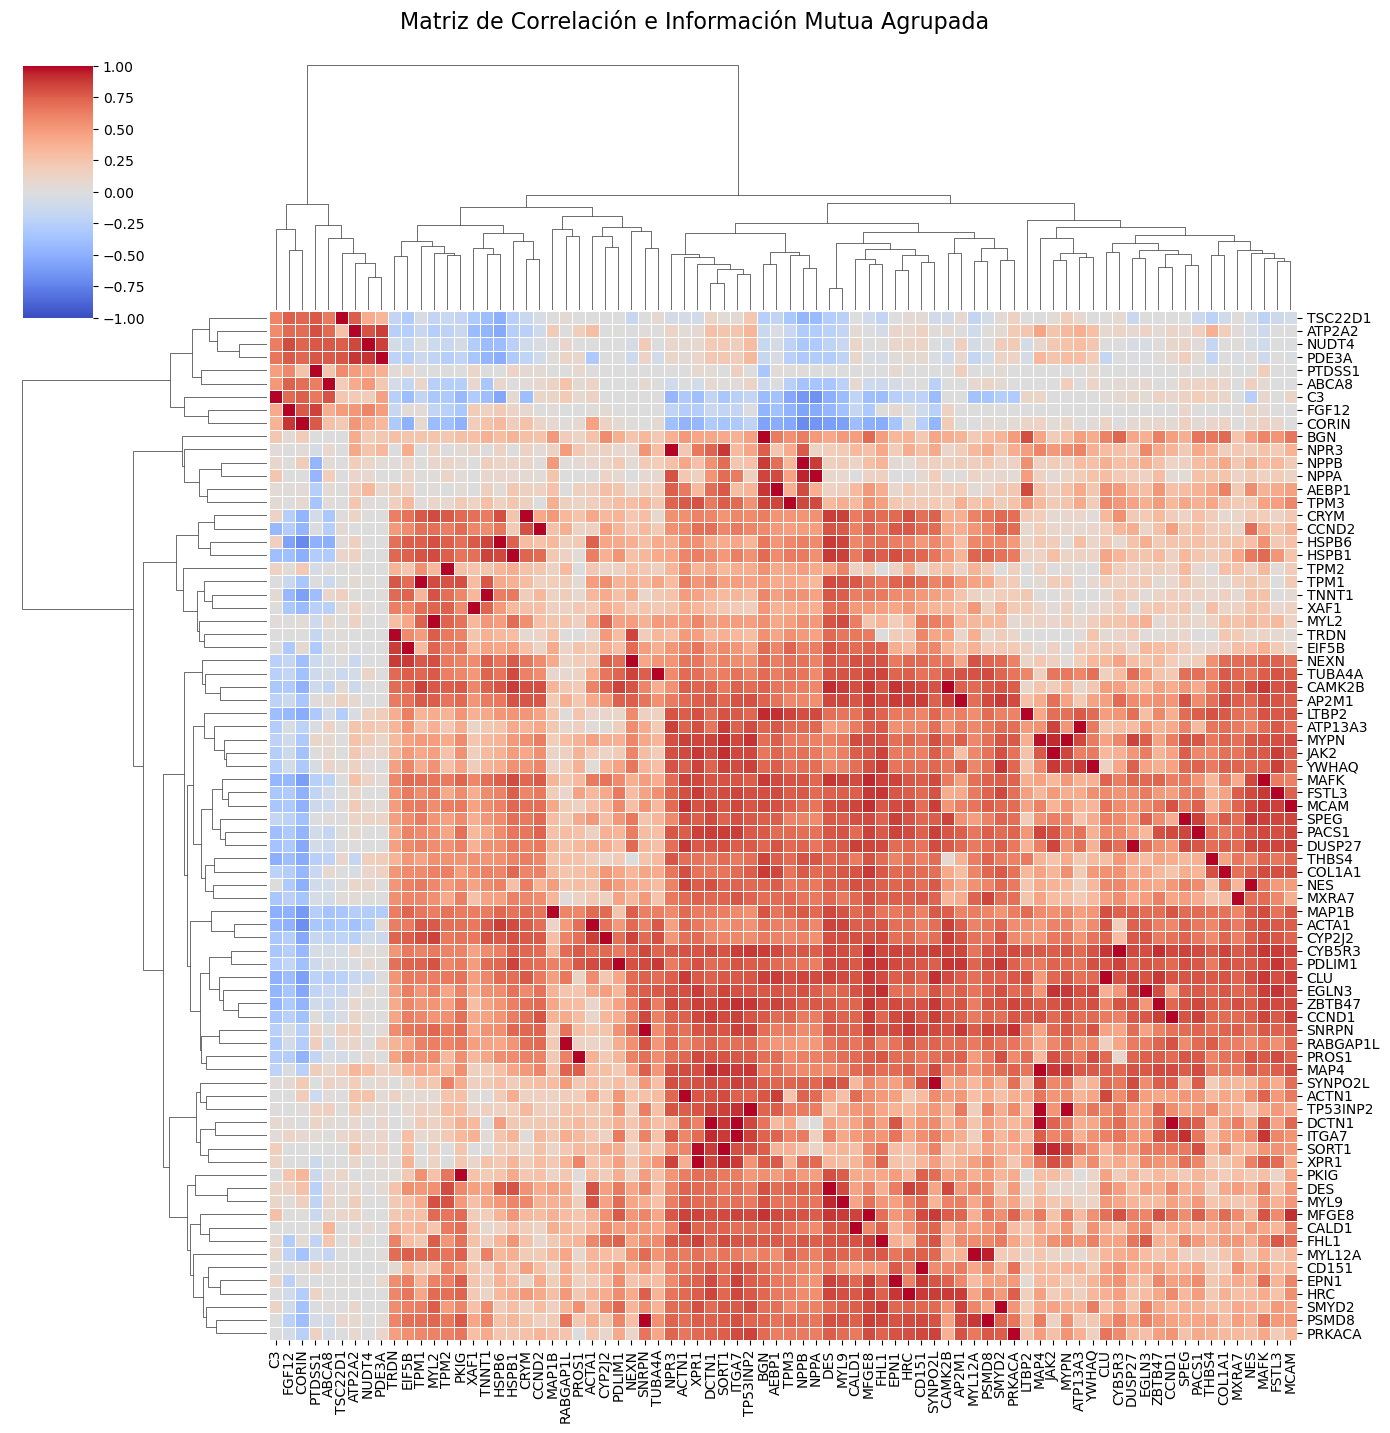

In [129]:
from sklearn.feature_selection import mutual_info_regression

corr = df1.corr(method='spearman')  
mi_matrix = np.zeros_like(corr) 

for i in range(len(df1.columns)):
    for j in range(i+1, len(df1.columns)):
        mi = mutual_info_regression(df1[[df1.columns[i]]], df1[[df1.columns[j]]])[0]
        mi_matrix[i, j] = mi
        mi_matrix[j, i] = mi
combined_matrix = np.copy(corr)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # Máscara para el lado superior de la diagonal
combined_matrix[mask] = mi_matrix[mask]

cluster = sns.clustermap(combined_matrix,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7},
                         xticklabels=df1.columns,
                         yticklabels=df1.columns) 
cluster.fig.suptitle('Matriz de Correlación e Información Mutua Agrupada', y=1.02, fontsize=16)
cluster.fig.savefig("../graphics/clustermap_correlacion_informacion_mutuaProteinas.png", bbox_inches='tight', dpi=300)

plt.show()

### Clustering

In [ ]:
from sklearn.metrics import silhouette_score

#### Kmeans

In [338]:
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
import warnings
warnings.filterwarnings('ignore')

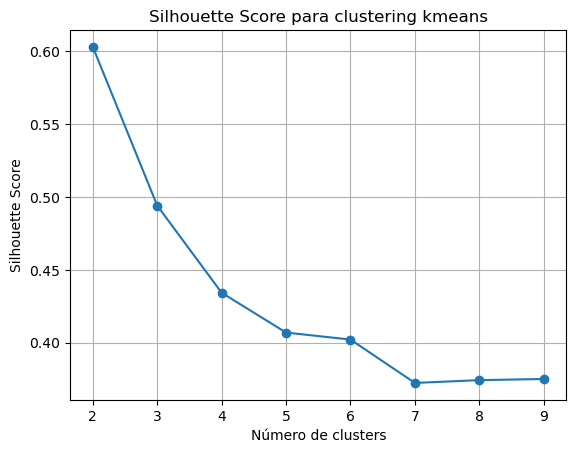

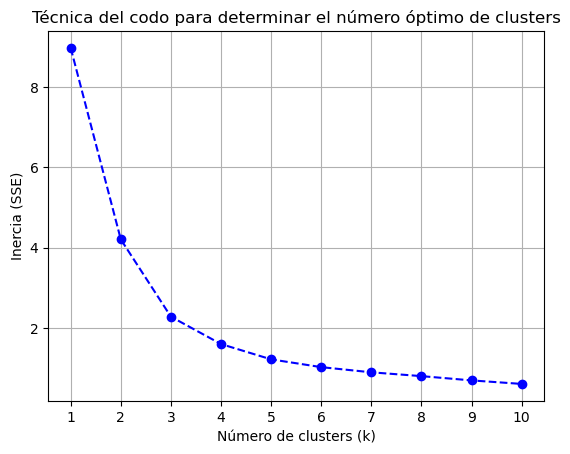

In [343]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)


sil_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_mds)
    sil = silhouette_score(X_mds, labels)
    sil_scores.append(sil)

plt.plot(range(2, 10), sil_scores, marker='o')
plt.title('Silhouette Score para clustering kmeans')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_mds)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o', color='b', linestyle='--')
plt.title('Técnica del codo para determinar el número óptimo de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (SSE)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


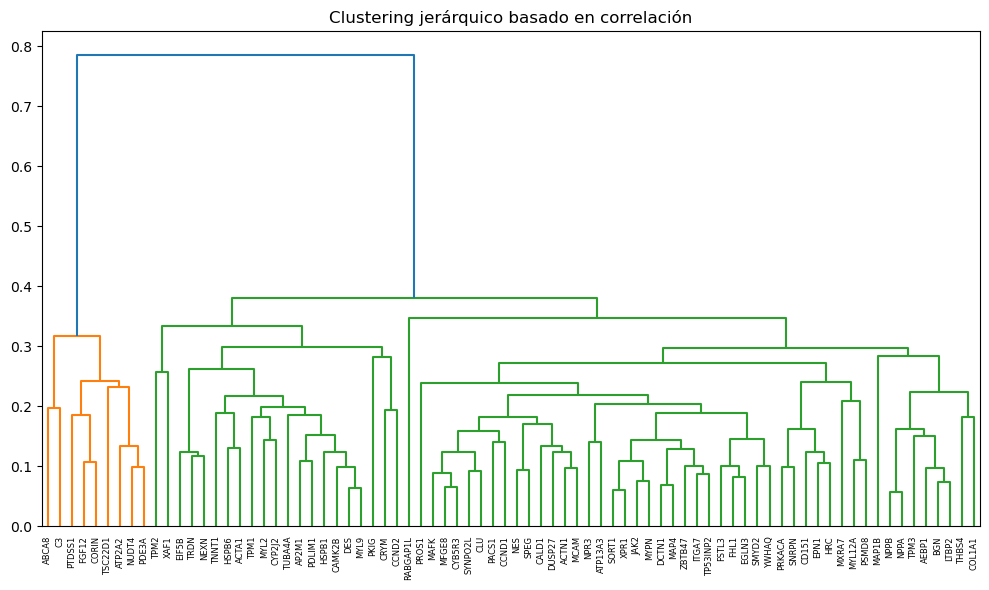

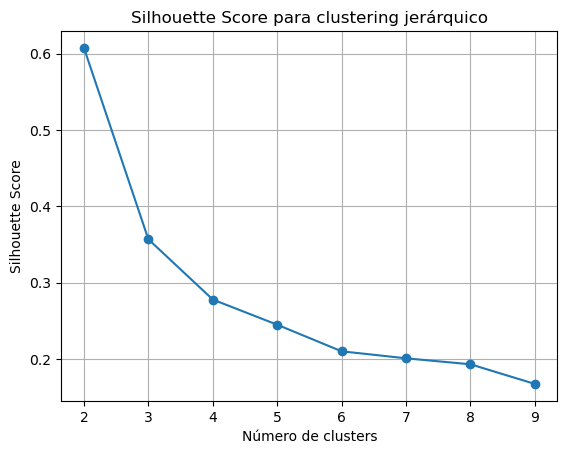

In [337]:
from scipy.cluster.hierarchy import linkage, dendrogram,fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score


corr = df1.corr(method='spearman') 
dist = 1 - corr.abs()


dist_vec = squareform(dist.values)

Z = linkage(dist_vec, method='average') 


plt.figure(figsize=(10, 6))
dendrogram(Z, labels=corr.columns, leaf_rotation=90)
plt.title('Clustering jerárquico basado en correlación')
plt.tight_layout()
plt.show()

Z = linkage(dist_vec, method='average') 
sil_scores = []
for k in range(2, 10):
    labels = fcluster(Z, t=k, criterion='maxclust')
    sil = silhouette_score(dist, labels, metric='precomputed')
    sil_scores.append(sil)

plt.plot(range(2, 10), sil_scores, marker='o')
plt.title('Silhouette Score para clustering jerárquico')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

En base a la correlación mínima en cada cluster y a la correlación máxima entre clusters

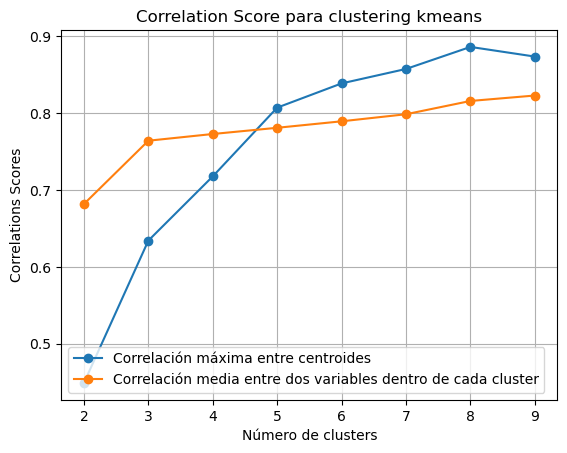

In [351]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)

mincorr_scores_mean = []
meancorr_scores_mean = []
centroidesMaxcorr_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_mds)
    cluster_df = pd.DataFrame({'variable': corr.columns, 'cluster': labels})
    closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_mds) #sacar centroide
    variables_cercanas = corr.columns[closest]
    df_centroides = df1[variables_cercanas]
    corr_values = abs(df_centroides.corr().values.copy())
    np.fill_diagonal(corr_values, np.nan)
    max_corr = np.nanmax(corr_values)
    centroidesMaxcorr_scores.append(max_corr)
    mincorr_scores = []
    meancorr_scores = []
    for cl in range(k):
        vars_cl = cluster_df[cluster_df['cluster'] == cl]['variable'].to_list()
        df_cluster_i = df1[vars_cl]
        correlaciones_cl = abs(df_cluster_i.corr(method='spearman'))
        mincorr = correlaciones_cl.min().min()
        meancorr = correlaciones_cl.mean().mean()
        mincorr_scores.append(mincorr)
        meancorr_scores.append(meancorr)
    mincorr_scores_mean.append(np.mean(mincorr_scores))
    meancorr_scores_mean.append(np.mean(meancorr_scores))

#plt.plot(range(2, 10), mincorr_scores_mean, marker='o', label = 'Correlación mínima entre dos variables dentro de cada cluster')
plt.plot(range(2, 10), centroidesMaxcorr_scores, marker='o', label = 'Correlación máxima entre centroides')
plt.plot(range(2, 10), meancorr_scores_mean, marker='o', label = 'Correlación media entre dos variables dentro de cada cluster')
plt.title('Correlation Score para clustering kmeans')
plt.xlabel('Número de clusters')
plt.ylabel('Correlations Scores')
plt.grid(True)
plt.legend()
plt.show()

En base a la Info mutua  mínima en cada cluster y a la Info mutua máxima entre clusters

In [348]:
def infoCruzadaMatrix (df):
    corr = df.corr()
    mi_matrix = np.zeros_like(corr) 

    for i in range(len(df.columns)):
        for j in range(i+1, len(df.columns)):
            mi = mutual_info_regression(df[[df.columns[i]]], df[[df.columns[j]]])[0]
            mi_matrix[i, j] = mi
            mi_matrix[j, i] = mi
    mi_df = pd.DataFrame(mi_matrix, index=df.columns, columns=df.columns)
    return mi_df

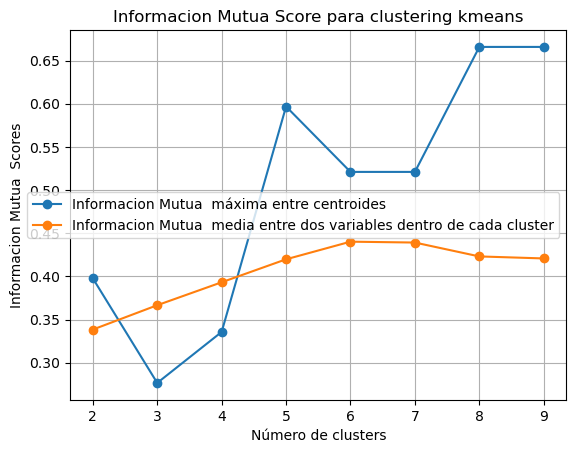

In [350]:
mi_df = infoCruzadaMatrix (df1)
dist = 1 - mi_df.abs()
dist_matrix = dist.values

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)

minMI_scores_mean = []
meanMI_scores_mean = []
centroidesMaxMI_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_mds)
    cluster_df = pd.DataFrame({'variable': mi_df.columns, 'cluster': labels})
    closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_mds) #sacar centroide
    variables_cercanas = mi_df.columns[closest]
    df_centroides = df1[variables_cercanas]
    df_centrMI = infoCruzadaMatrix (df_centroides)
    MI_values = abs(df_centrMI.values.copy())
    np.fill_diagonal(MI_values, np.nan)
    max_MI = np.nanmax(MI_values)
    centroidesMaxMI_scores.append(max_MI)
    minMI_scores = []
    meanMI_scores = []
    for cl in range(k):
        vars_cl = cluster_df[cluster_df['cluster'] == cl]['variable'].to_list()
        df_cluster_i = df1[vars_cl]
        df_clMI = infoCruzadaMatrix (df_cluster_i)
        MI_cl = abs(df_clMI)
        minMI = MI_cl.min().min()
        meanMI = MI_cl.mean().mean()
        minMI_scores.append(minMI)
        meanMI_scores.append(meanMI)
    minMI_scores_mean.append(np.mean(minMI_scores))
    meanMI_scores_mean.append(np.mean(meanMI_scores))

#plt.plot(range(2, 10), minMI_scores_mean, marker='o', label = 'Informacion Mutua  mínima entre dos variables dentro de cada cluster')
plt.plot(range(2, 10), centroidesMaxMI_scores, marker='o', label = 'Informacion Mutua  máxima entre centroides')
plt.plot(range(2, 10), meanMI_scores_mean, marker='o', label = 'Informacion Mutua  media entre dos variables dentro de cada cluster')
plt.title('Informacion Mutua Score para clustering kmeans')
plt.xlabel('Número de clusters')
plt.ylabel('Informacion Mutua  Scores')
plt.grid(True)
plt.legend()
plt.show()

Elegimos 3 grupos

In [363]:
threshold

np.float64(0.3807616686178646)

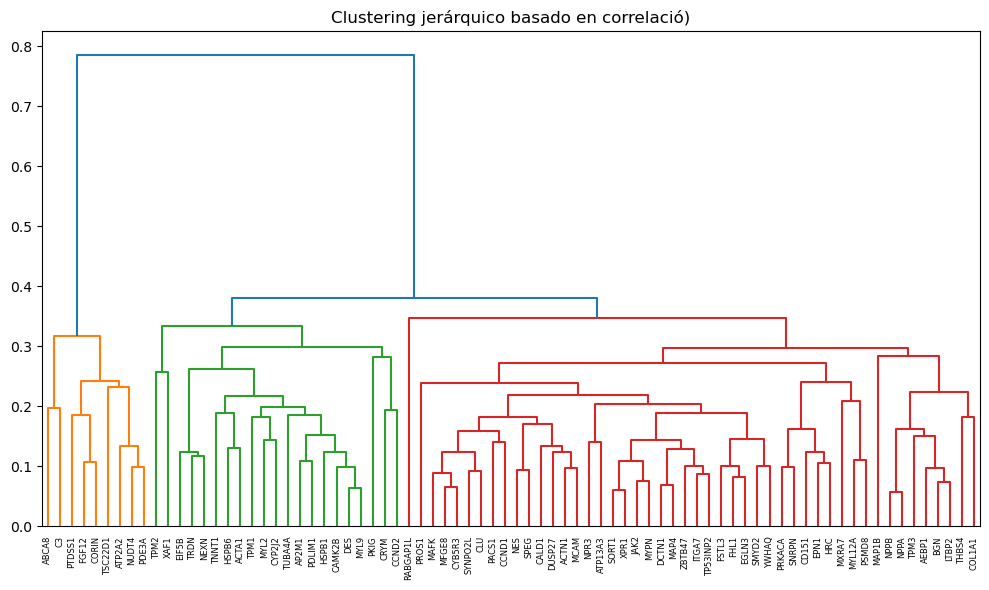

In [369]:
labels_jerar = fcluster(Z, t=3, criterion='maxclust')

threshold = Z[-3 + 1, 2] 
cluster_dfjerar = pd.DataFrame({'variable': corr.columns, 'clusterJerarquico': labels_jerar})
# Dibuja dendrograma con color_threshold
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=corr.columns, leaf_rotation=90, color_threshold=threshold)
plt.title('Clustering jerárquico basado en correlació)')
plt.tight_layout()
plt.show()

In [370]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)
kmeans = KMeans(n_clusters=3, random_state=42)
labelskmeans = kmeans.fit_predict(X_mds)
cluster_df_kmeans = pd.DataFrame({'variable': corr.columns, 'clusterKmeans': labelskmeans})

In [374]:
cluster_df = pd.merge(cluster_dfjerar,cluster_df_kmeans, on = 'variable')

In [379]:
cluster_df[cluster_df['clusterJerarquico'] == 1]

,variable,clusterJerarquico,clusterKmeans
1,PTDSS1,1,2
23,FGF12,1,2
27,CORIN,1,2
30,ABCA8,1,2
40,C3,1,2
47,ATP2A2,1,2
59,TSC22D1,1,2
68,NUDT4,1,2
73,PDE3A,1,2


In [380]:
cluster_df[cluster_df['clusterJerarquico'] == 2]

,variable,clusterJerarquico,clusterKmeans
13,TPM2,2,0
15,DES,2,0
16,MYL9,2,0
18,PKIG,2,0
20,MYL2,2,0
22,TRDN,2,0
25,EIF5B,2,0
29,TNNT1,2,0
31,TPM1,2,0
34,XAF1,2,0


In [381]:
cluster_df[cluster_df['clusterJerarquico'] == 3]

,variable,clusterJerarquico,clusterKmeans
0,BGN,3,1
2,DCTN1,3,1
3,SORT1,3,1
4,NPPB,3,1
5,NPR3,3,1
6,AEBP1,3,1
7,ITGA7,3,1
8,NPPA,3,1
9,XPR1,3,1
10,ACTN1,3,1


Visualizar

In [466]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_mds)
cluster_df = pd.DataFrame({'variable': mi_df.columns, 'cluster': labels})
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_mds) #sacar centroide
variables_cercanas = df1.columns[closest]
df_centroides = df1[variables_cercanas]

In [478]:
coords_df

,variable,x,y,cluster
0,BGN,-0.032886,0.150925,1
1,PTDSS1,-0.742017,0.027414,2
2,DCTN1,0.174684,0.135027,1
3,SORT1,0.136024,0.194307,1
4,NPPB,-0.085019,0.279729,1
...,...,...,...,...
73,PDE3A,-0.723791,-0.138972,2
74,CYP2J2,0.088452,-0.224232,0
75,CYB5R3,0.162738,0.100743,1
76,MAP1B,-0.125824,0.063903,1


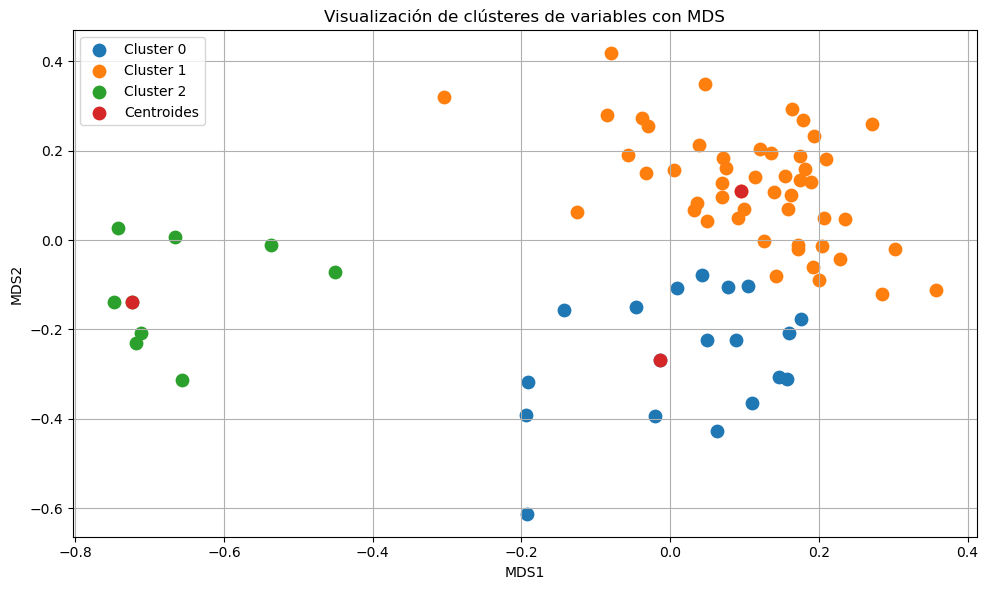

In [479]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)

coords_df = pd.DataFrame({
    'variable': mi_df.columns,
    'x': X_mds[:, 0],
    'y': X_mds[:, 1],
    'cluster': cluster_df['cluster']   # los labels que te salieron de KMeans o jerárquico
})

plt.figure(figsize=(10, 6))
for cl in sorted(coords_df['cluster'].unique()):
    sub = coords_df[coords_df['cluster'] == cl]
    plt.scatter(sub['x'], sub['y'], label=f'Cluster {cl}', s=80)

vars_centroids = coords_df[coords_df['variable'].isin(variables_cercanas)]    
plt.scatter(vars_centroids['x'], vars_centroids['y'], label=f'Centroides', s=80)
#for _, row in coords_df.iterrows():
 #   plt.text(row['x'], row['y'], row['variable'], fontsize=8, alpha=0.6)

plt.title('Visualización de clústeres de variables con MDS')
plt.xlabel('MDS1')
plt.ylabel('MDS2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [447]:
df1_tras = df1.T.reset_index().rename(columns = {'index': 'variable'})
df1_tras_cluster = pd.merge(cluster_df, df1_tras)

In [455]:
df1_cluster0 = df1_tras_cluster[df1_tras_cluster['clusterKmeans'] == 0].set_index('variable').drop(columns = ['clusterKmeans','clusterJerarquico']).T
df1_cluster1 = df1_tras_cluster[df1_tras_cluster['clusterKmeans'] == 1].set_index('variable').drop(columns = ['clusterKmeans','clusterJerarquico']).T
df1_cluster2 = df1_tras_cluster[df1_tras_cluster['clusterKmeans'] == 2].set_index('variable').drop(columns = ['clusterKmeans','clusterJerarquico']).T

### Reducir variables redundantes

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [598]:
df1_clusters = [df1_cluster0,df1_cluster1,df1_cluster2]
df1_pca_list = []
for cl in range(3):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df1_clusters[cl])
    pca = PCA(n_components=1)
    X_pca = pca.fit_transform(X_scaled)
    df_pca = pd.DataFrame(X_pca,columns=[f'Clus{cl}' for i in range(X_pca.shape[1])],index=df1_clusters[cl].index)
    df1_pca_list.append(df_pca)
df2 = pd.concat(df1_pca_list,axis = 1)
print(len(df1.columns), 'variables =>', len(df2.columns), 'variables')

78 variables => 3 variables


### Árbol de clasificación

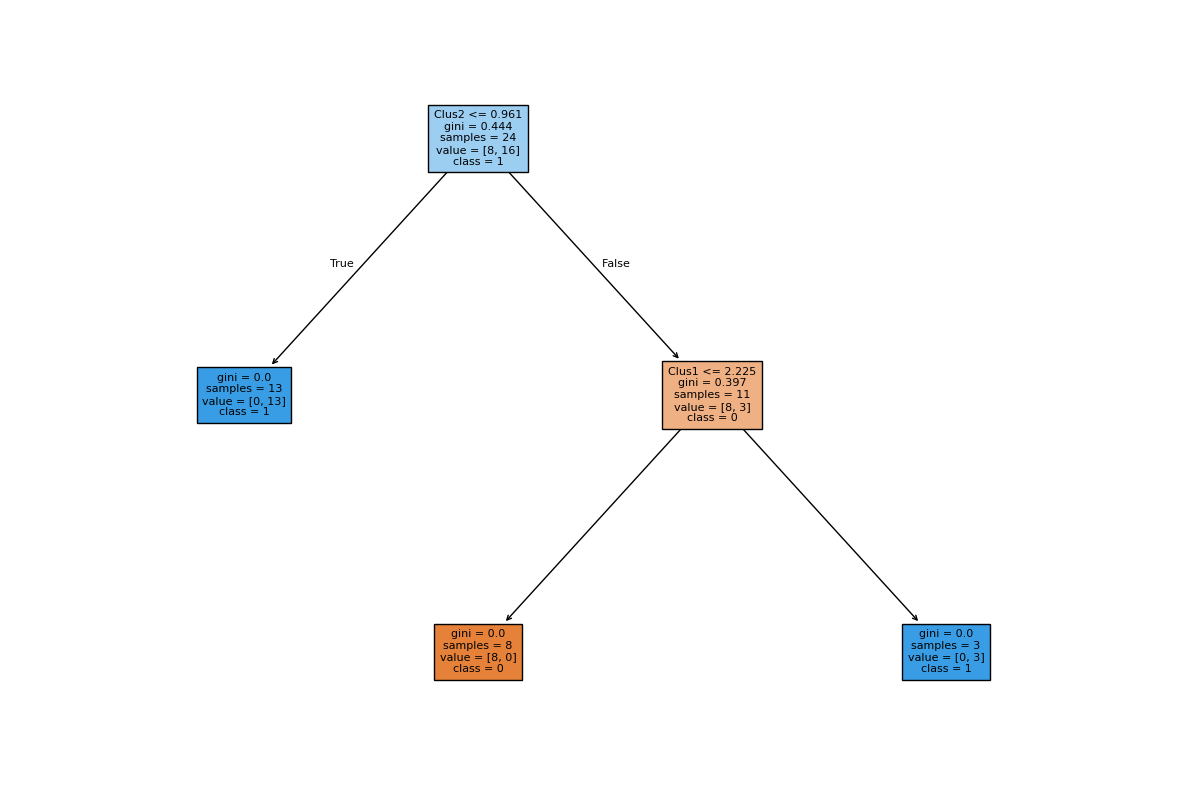

In [599]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

df3 = df2.copy().reset_index()
df3['Grupo'] = np.where(df3['index'].str.contains('A'), 'Tratamiento', 
              np.where(df3['index'].str.contains('C'), 'Control', 'Otro'))
df3 = df3.set_index('index')
df3 = pd.get_dummies(df3, columns=['Grupo'], drop_first=True)
df3['Grupo_Tratamiento'] = df3['Grupo_Tratamiento'].astype(int)

X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Evaluar
accuracy = clf.score(X_test, y_test)

plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    filled=True,
    feature_names=X.columns,
    class_names=[str(c) for c in clf.classes_],
    fontsize=8  # Tamaño de fuente más pequeño
)
plt.tight_layout() 
plt.show()

### Random Forests

In [600]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score,cross_val_predict, train_test_split
from sklearn.metrics  import roc_curve, auc, accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


df3 = df2.copy().reset_index()
df3['Grupo'] = np.where(df3['index'].str.contains('A'), 'Tratamiento', 
              np.where(df3['index'].str.contains('C'), 'Control', 'Otro'))
df3 = df3.set_index('index')
df3 = pd.get_dummies(df3, columns=['Grupo'], drop_first=True)
df3['Grupo_Tratamiento'] = df3['Grupo_Tratamiento'].astype(int)

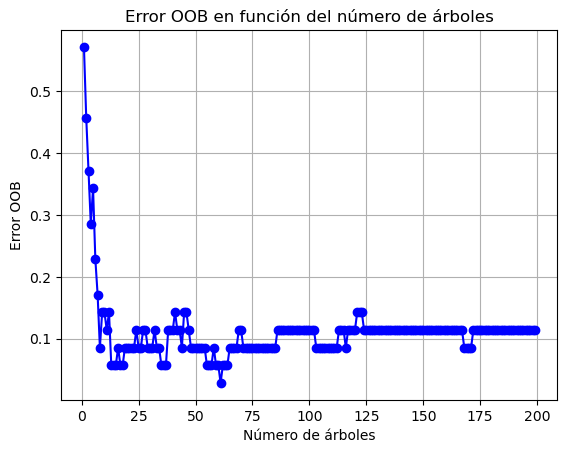

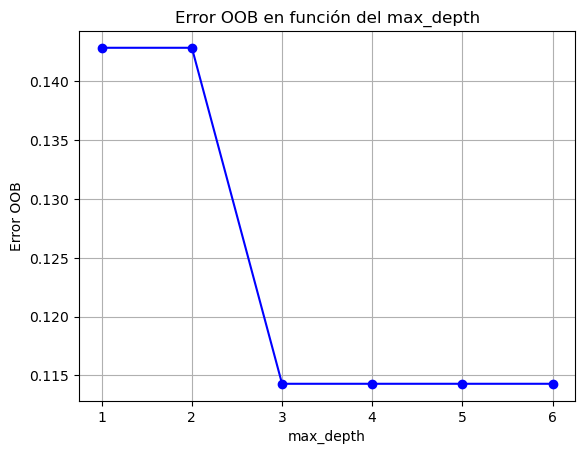

In [602]:
X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]
estimadores = range(1, 200, 1)
oob_errors = []

for n_estimators in estimadores:  
    rf = RandomForestClassifier(n_estimators=n_estimators, oob_score=True, random_state=42)
    rf.fit(X, y)
    oob_errors.append(1 - rf.oob_score_) 

plt.plot(estimadores, oob_errors, marker='o', color='b')
plt.xlabel('Número de árboles')
plt.ylabel('Error OOB')
plt.title('Error OOB en función del número de árboles')
plt.grid(True)
plt.show()

oob_errors = []
profundidades = range(1, 7)
for max_depth in profundidades:  
    rf = RandomForestClassifier(n_estimators=300, max_depth=max_depth, oob_score=True, random_state=42)
    rf.fit(X, y)
    oob_errors.append(1 - rf.oob_score_) 

plt.plot(profundidades, oob_errors, marker='o', color='b')
plt.xlabel('max_depth')
plt.ylabel('Error OOB')
plt.title('Error OOB en función del max_depth')
plt.grid(True)
plt.show()

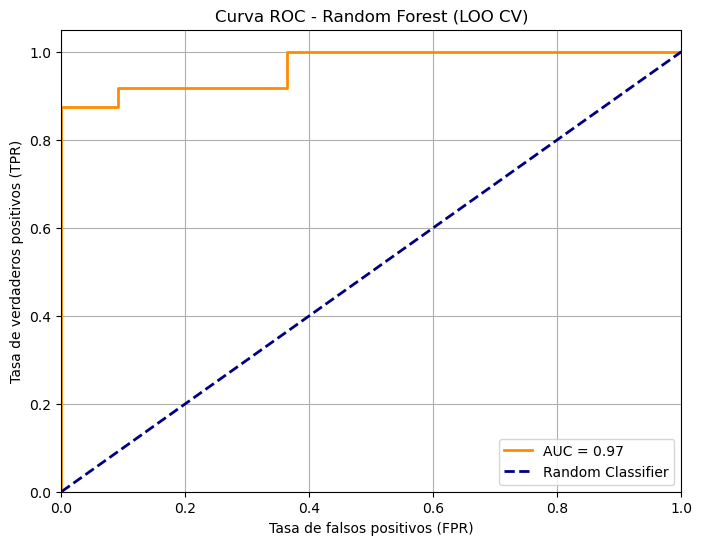

Precisión media en entrenamiento: 1.0
Precisión media en test: 0.8857142857142857
AUC de la curva ROC: 0.9659090909090909
Tasa de verdaderos negativos (TNR - especificidad): 0.8181818181818182
Tasa de falsos negativos (FNR): 0.08333333333333333
Tasa de verdaderos  positivos (TPR): 0.9166666666666666
Tasa de falsos positivos (FPR): 0.18181818181818182


In [603]:
n_estimators = 300
max_depth = 3

X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]

# Inicializar LOO
loo = LeaveOneOut()

# Acumuladores
accuracies_train = []
accuracies_test = []
y_true = []
y_pred_proba = []
y_pred_class = []
modelos = []
importancias = []
# Loop LOO
for train_index, test_index in loo.split(X):
    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    
    rf.fit(X_train, y_train)

    # Predicciones
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_test_proba = rf.predict_proba(X_test)[:, 1]

    # Guardar resultados
    accuracies_train.append(accuracy_score(y_train, y_train_pred))
    accuracies_test.append(accuracy_score(y_test, y_test_pred))
    y_true.append(y_test.values[0])
    y_pred_proba.append(y_test_proba[0])
    y_pred_class.append(y_test_pred[0])
    importances = rf.feature_importances_
    feature_names = X.columns
    feat_importances = pd.DataFrame(importances, index=feature_names).T
    importancias.append(feat_importances)
    modelos.append(rf)
importancias = pd.concat(importancias)
# Calcular AUC y ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Matriz de confusión agregada
cm = confusion_matrix(y_true, y_pred_class)
TN, FP, FN, TP = cm.ravel()

# Métricas adicionales
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

# Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest (LOO CV)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Resultados
print("Precisión media en entrenamiento:", np.mean(accuracies_train))
print("Precisión media en test:", np.mean(accuracies_test))
print("AUC de la curva ROC:", roc_auc)
print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
print("Tasa de falsos negativos (FNR):", FNR)
print("Tasa de verdaderos  positivos (TPR):", TPR)
print("Tasa de falsos positivos (FPR):", FPR)

In [604]:
importancias.mean().sort_values(ascending = False)

Clus2    0.357578
Clus0    0.350549
Clus1    0.291873
dtype: float64

In [605]:
df3.corr()['Grupo_Tratamiento']

Clus0                0.645828
Clus1                0.550204
Clus2               -0.679441
Grupo_Tratamiento    1.000000
Name: Grupo_Tratamiento, dtype: float64

### Logística

In [606]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [607]:
def discretizar_variables(df, n_bins):
    """
    Discretiza las variables continuas usando una cantidad definida de intervalos.
    """
    df_discretized = df.copy()
    for col in df.columns:
        df_discretized[col] = pd.qcut(df[col], q=n_bins, labels=False, duplicates='drop')
    data_encoded = pd.DataFrame()
    for col in df_discretized.columns:
        dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
        dummies = dummies.drop(columns=[col + '_bajo'], errors='ignore')  # 'errors="ignore"' maneja el caso de que no exista esa columna
        data_encoded = pd.concat([data_encoded, dummies], axis=1)
    data_encoded = data_encoded.astype(int)

    return data_encoded

df4 = discretizar_variables(df2, 3)
df4 = pd.concat([df4,df3['Grupo_Tratamiento']], axis = 1)

Exactitud: 0.86
AUC: 1.00


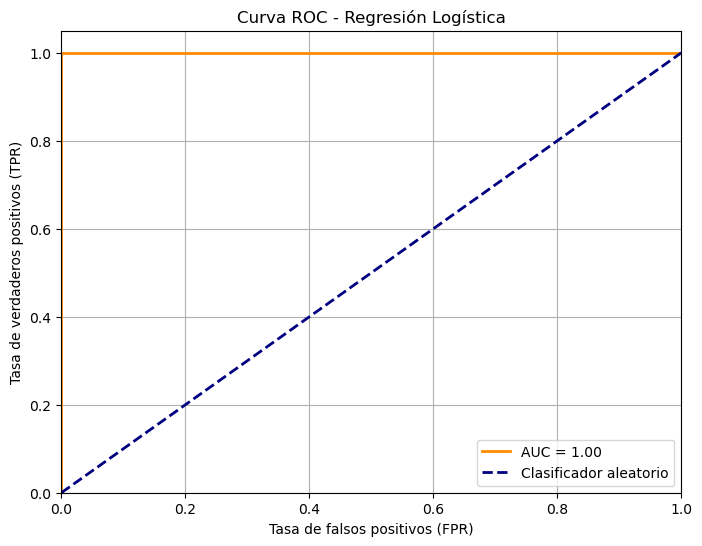

Coeficientes del modelo:


,Característica,Coeficiente
1,Clus0_1,0.181423
2,Clus0_2,0.099838
5,Clus1_2,2.149828
6,Clus2_0,1.482791
7,Clus2_1,0.002123
8,Clus2_2,-1.126194


In [608]:
X = df4.drop(columns=["Grupo_Tratamiento"])  
y = df4["Grupo_Tratamiento"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(penalty='l1', solver='liblinear')

# Entrenar el modelo
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1] 

accuracy = accuracy_score(y_test, y_pred)
print(f'Exactitud: {accuracy:.2f}')



fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
print(f'AUC: {roc_auc:.2f}')

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


coefficients = pd.DataFrame({
    'Característica': X.columns,
    'Coeficiente': log_reg.coef_[0]
})
print("Coeficientes del modelo:")
coefficients[coefficients['Coeficiente'] != 0]